In [1468]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

Reading and processing dataset

In [1469]:
#1.loading the dataset
dataset = pd.read_csv('KDDTrain.csv')
#printing a few rows from the beggining of the dataset to have an idea of the data contained
dataset.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [1470]:
#printing few rows from the end of the dataset to have an idea of the data contained
dataset.tail()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.0,0.00,0.0,0.00,0.0,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.0,0.72,0.0,0.01,0.0,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.0,1.00,1.0,0.00,0.0,neptune,20
125972,0,tcp,ftp_data,SF,151,0,0,0,0,0,...,0.30,0.03,0.30,0.0,0.00,0.0,0.00,0.0,normal,21


In [1471]:
#sample the first 20 raws to visualize datapoints
dataset.sample(20)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,classnum
125217,0,udp,ntp_u,SF,48,48,0,0,0,0,...,0.27,0.04,0.27,0.00,0.00,0.0,0.0,0.00,normal,21
54145,0,tcp,private,REJ,0,0,0,0,0,0,...,0.09,0.06,0.00,0.00,0.00,0.0,1.0,1.00,neptune,19
39969,10,tcp,smtp,SF,781,390,0,0,0,0,...,0.61,0.22,0.06,0.00,0.11,0.0,0.0,0.00,normal,21
7765,0,udp,domain_u,SF,44,81,0,0,0,0,...,0.89,0.01,0.01,0.00,0.00,0.0,0.0,0.00,normal,18
31083,1,tcp,smtp,SF,1414,404,0,0,0,0,...,0.79,0.03,0.01,0.00,0.00,0.0,0.0,0.00,normal,21
12258,0,tcp,link,S0,0,0,0,0,0,0,...,0.00,0.07,0.00,0.00,1.00,1.0,0.0,0.00,neptune,18
9805,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.05,0.00,0.00,1.00,1.0,0.0,0.00,neptune,21
66916,0,tcp,imap4,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.0,0.0,0.00,neptune,20
82940,0,tcp,http,SF,198,326,0,0,0,0,...,1.00,0.00,0.02,0.04,0.00,0.0,0.0,0.00,normal,21
39700,0,tcp,ftp_data,SF,965,0,0,0,0,0,...,0.74,0.08,0.74,0.02,0.00,0.0,0.0,0.00,normal,21


In [1472]:
# Number of columns and row in the dataset
dataset.shape

(125973, 43)

In [1473]:
#numbers of datapoints in database
len(dataset)

125973

In [1474]:
#Printing a statistical overview of the data
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [1475]:
# visualizing the attributes of the dataset
dataset.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class', 'classnum'],
      dtype='object')

In [1476]:
#dropping the columns wich we do not need, to have a simpler dataset
dataset=dataset.drop(columns=['duration','service','src_bytes','dst_bytes','land','wrong_fragment','urgent','num_outbound_cmds',
                              'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate','flag'],axis=1)

In [1477]:
dataset.shape

(125973, 16)

In [1478]:
#Determine data types in the dataset
dataset.dtypes

protocol_type         object
hot                    int64
num_failed_logins      int64
logged_in              int64
num_compromised        int64
root_shell             int64
su_attempted           int64
num_root               int64
num_file_creations     int64
num_shells             int64
num_access_files       int64
is_host_login          int64
is_guest_login         int64
count                  int64
class                 object
classnum               int64
dtype: object

In [1479]:
#changing the data points type to be more accurate 
dataset['protocol_type'] = dataset['protocol_type'].astype("string")

In [1480]:
dataset['class'] = dataset['class'].astype("string")

In [1481]:
#visualising the new types of data
dataset.dtypes

protocol_type         string[python]
hot                            int64
num_failed_logins              int64
logged_in                      int64
num_compromised                int64
root_shell                     int64
su_attempted                   int64
num_root                       int64
num_file_creations             int64
num_shells                     int64
num_access_files               int64
is_host_login                  int64
is_guest_login                 int64
count                          int64
class                 string[python]
classnum                       int64
dtype: object

In [1482]:
#counting the number of null values in dataset
dataset.isnull().sum()

protocol_type         0
hot                   0
num_failed_logins     0
logged_in             0
num_compromised       0
root_shell            0
su_attempted          0
num_root              0
num_file_creations    0
num_shells            0
num_access_files      0
is_host_login         0
is_guest_login        0
count                 0
class                 0
classnum              0
dtype: int64

In [1483]:
#counting duplicates -we have no duplicates
dataset.duplicated().sum()

118632

Data Exploration with Pandas

In [1484]:
print('Number of occurences of specific protocols in the dataset')
dataset['protocol_type'].value_counts()

Number of occurences of specific protocols in the dataset


protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: Int64

<Axes: xlabel='protocol_type', ylabel='count'>

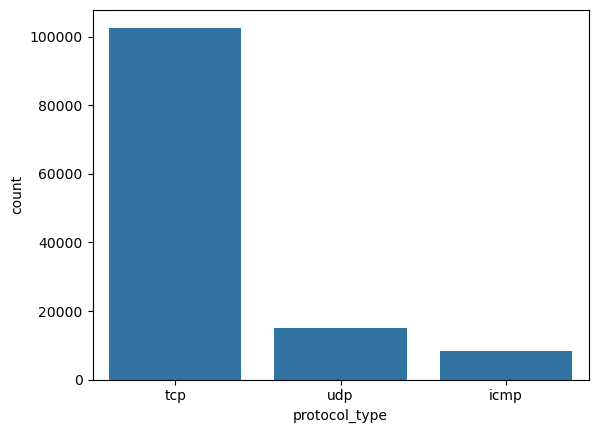

In [1485]:
sns.countplot(data=dataset,
              x="protocol_type")

In [1486]:
print('The occurrences of specific protocols in the dataset/percentage wise') 
dataset['protocol_type'].value_counts(normalize=True) * 100

The occurrences of specific protocols in the dataset/percentage wise


protocol_type
tcp     81.516674
udp     11.901757
icmp     6.581569
Name: proportion, dtype: Float64

In [1487]:
print('Number of occurences of specific atack types in the dataset')
dataset['class'].value_counts()

Number of occurences of specific atack types in the dataset


class
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: Int64

In [1488]:
print('Number of occurences of specific atack types in the dataset')
dataset['class'].value_counts(normalize=True) * 100

Number of occurences of specific atack types in the dataset


class
normal             53.458281
neptune            32.716534
satan               2.883951
ipsweep             2.856961
portsweep           2.326689
smurf                2.10045
nmap                1.185175
back                0.758893
teardrop            0.708088
warezclient         0.706501
pod                 0.159558
guess_passwd        0.042073
buffer_overflow     0.023815
warezmaster         0.015876
land                0.014289
imap                0.008732
rootkit             0.007938
loadmodule          0.007144
ftp_write           0.006351
multihop            0.005557
phf                 0.003175
perl                0.002381
spy                 0.001588
Name: proportion, dtype: Float64

In [1489]:
print('Number of times a port was been accesed in the connection, (port number/number of times)')
import matplotlib.pyplot as plt
dataset['hot'].value_counts()

Number of times a port was been accesed in the connection, (port number/number of times)


hot
0     123302
2       1037
1        369
28       277
30       256
4        173
6        140
5         76
24        68
19        57
22        55
3         54
18        45
14        30
20         9
7          5
15         4
11         3
25         2
9          2
44         2
77         1
17         1
12         1
10         1
8          1
21         1
33         1
Name: count, dtype: int64

In [1490]:
print('The occurrences of accessing a specific port in the dataset/percentage wise (port number/percentage)')
dataset['hot'].value_counts(normalize=True) * 100

The occurrences of accessing a specific port in the dataset/percentage wise (port number/percentage)


hot
0     97.879704
2      0.823192
1      0.292920
28     0.219888
30     0.203218
4      0.137331
6      0.111135
5      0.060330
24     0.053980
19     0.045248
22     0.043660
3      0.042866
18     0.035722
14     0.023815
20     0.007144
7      0.003969
15     0.003175
11     0.002381
25     0.001588
9      0.001588
44     0.001588
77     0.000794
17     0.000794
12     0.000794
10     0.000794
8      0.000794
21     0.000794
33     0.000794
Name: proportion, dtype: float64

In [1491]:
print('Number of times the login was succefull (1-yes, 0-no)')
dataset['logged_in'].value_counts()

Number of times the login was succefull (1-yes, 0-no)


logged_in
0    76121
1    49852
Name: count, dtype: int64

In [1492]:
print('Number of times the login was succefull (1-yes, 0-no) in the dataset/percentage wise') 
dataset['logged_in'].value_counts(normalize=True) * 100

Number of times the login was succefull (1-yes, 0-no) in the dataset/percentage wise


logged_in
0    60.426441
1    39.573559
Name: proportion, dtype: float64

In [1493]:
print('Number of times the root shell was obtained during the connection (1-yes, 0-no)')
dataset['root_shell'].value_counts()

Number of times the root shell was obtained during the connection (1-yes, 0-no)


root_shell
0    125804
1       169
Name: count, dtype: int64

In [1494]:
print('Number of times a user attempted to switch to root user per connection (0-bening connection, 2-r2l class attack,1-probe class attack)')
dataset['su_attempted'].value_counts()

Number of times a user attempted to switch to root user per connection (0-bening connection, 2-r2l class attack,1-probe class attack)


su_attempted
0    125893
2        59
1        21
Name: count, dtype: int64

In [1495]:
#number of shells opened during a connection
dataset['num_shells'].value_counts()

num_shells
0    125926
1        42
2         5
Name: count, dtype: int64

In [1496]:
#number of times a login to the host was attempted (1-yes, 0-no)
dataset['is_host_login'].value_counts()

is_host_login
0    125972
1         1
Name: count, dtype: int64

In [1497]:
#number of times a guest login was attempted (1-yes, 0-no)
dataset['is_guest_login'].value_counts()

is_guest_login
0    124786
1      1187
Name: count, dtype: int64

In [1498]:
#mapping dictionary with class attack type per each attack type
attack_map = {
    'benign': ['normal'],
    'probe': ['nmap', 'ipsweep', 'portsweep', 'satan', 'mscan', 'saint', 'worm','ipsweep'],
    'r2l': ['ftp_write', 'guess_passwd', 'snmpguess', 'imap', 'spy', 'warezclient',
            'warezmaster', 'multihop', 'phf', 'named', 'sendmail', 'xlock', 'xsnoop', 'worm'],
    'u2r': ['ps', 'buffer_overflow', 'perl', 'rootkit', 'loadmodule', 'xtern',
            'sqlattack', 'httptunnel'],
    'dos': ['apache2', 'back', 'mailbomb', 'processtable', 'snmpgetattack', 'teardrop',
            'smurf', 'land', 'neptune', 'pod', 'udpstorm']
}


In [1499]:
# Reverse the mapping so we can look up category by value
label_map = {}
for category, labels in attack_map.items():
    for label in labels:
        label_map[label] = category

# Apply the mapping to create a new column
dataset['class_category'] = dataset['class'].map(label_map)

# Save to a new CSV 
dataset.to_csv('classified_output.csv', index=False)

# Preview result
print('The taxonomy of the attack type in the specific attack class')
print(dataset[['class', 'class_category']])


The taxonomy of the attack type in the specific attack class
          class class_category
0        normal         benign
1        normal         benign
2       neptune            dos
3        normal         benign
4        normal         benign
...         ...            ...
125968  neptune            dos
125969   normal         benign
125970   normal         benign
125971  neptune            dos
125972   normal         benign

[125973 rows x 2 columns]


In [1500]:
#number of datapoints for each atack category
dataset['class_category'].value_counts()

class_category
benign    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

<Axes: xlabel='class_category', ylabel='count'>

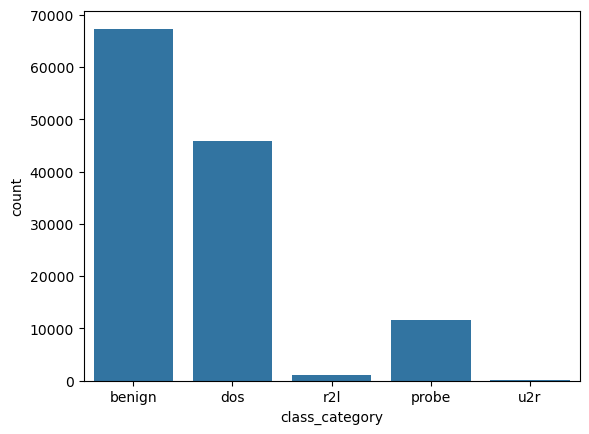

In [1501]:
sns.countplot(data=dataset,
              x="class_category")

In [1502]:
#determine how many bening and atacks are for each protocol
grouped = dataset.groupby(['protocol_type', 'class_category'])
# To count the number of rows in each group:
group_counts = grouped.size().reset_index(name='count')
# Display result
print(group_counts)

   protocol_type class_category  count
0           icmp         benign   1309
1           icmp            dos   2847
2           icmp          probe   4135
3            tcp         benign  53600
4            tcp            dos  42188
5            tcp          probe   5857
6            tcp            r2l    995
7            tcp            u2r     49
8            udp         benign  12434
9            udp            dos    892
10           udp          probe   1664
11           udp            u2r      3


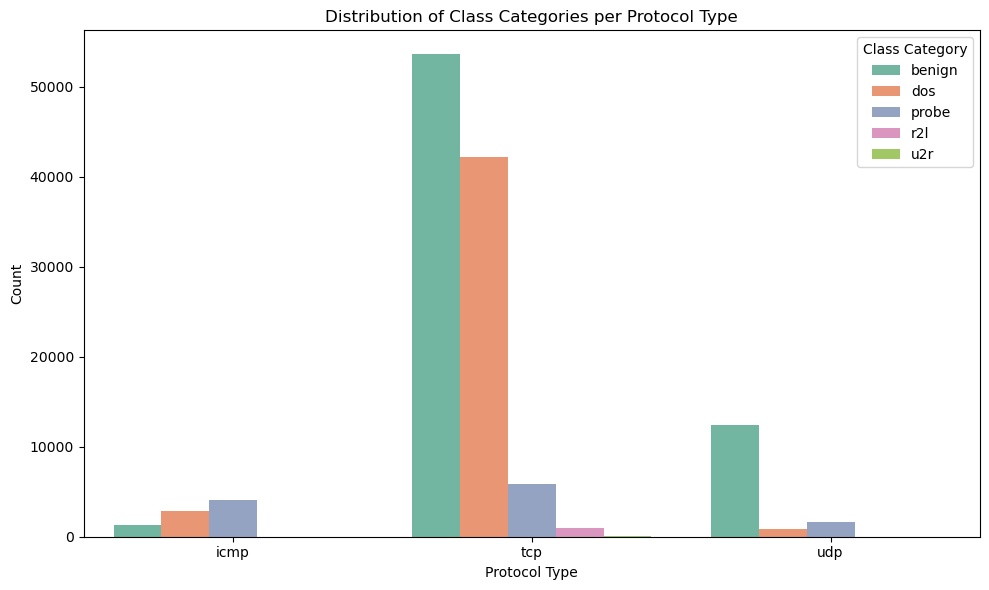

In [1503]:
data = {
    'protocol_type': ['icmp', 'icmp', 'icmp',
                      'tcp', 'tcp', 'tcp', 'tcp', 'tcp',
                      'udp', 'udp', 'udp', 'udp'],
    'class_category': ['benign', 'dos', 'probe',
                       'benign', 'dos', 'probe', 'r2l', 'u2r',
                       'benign', 'dos', 'probe', 'u2r'],
    'count': [1309, 2847, 4135,
              53600, 42188, 5857, 995, 49,
              12434, 892, 1664, 3]
}
df = pd.DataFrame(data)
# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='protocol_type', y='count', hue='class_category', palette='Set2')
plt.title('Distribution of Class Categories per Protocol Type')
plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.legend(title='Class Category')
plt.tight_layout()
plt.show()

In [1504]:
#how many times root access has been obtained by each attack type (1-yes, 0-no)
grouped = dataset.groupby(['root_shell', 'class_category'])
# To count the number of rows in each group:
group_counts = grouped.size().reset_index(name='count')
# Display result
print(group_counts)

   root_shell class_category  count
0           0         benign  67206
1           0            dos  45927
2           0          probe  11656
3           0            r2l    989
4           0            u2r     26
5           1         benign    137
6           1            r2l      6
7           1            u2r     26


In [1505]:
#Number of files accessed during the connection
grouped = dataset.groupby(['num_access_files', 'class_category'])
# To count the number of rows in each group:
group_counts = grouped.size().reset_index(name='count')
# Display result
print(group_counts)

    num_access_files class_category  count
0                  0         benign  66982
1                  0            dos  45927
2                  0          probe  11656
3                  0            r2l    986
4                  0            u2r     51
5                  1         benign    304
6                  1            r2l      8
7                  1            u2r      1
8                  2         benign     28
9                  2            r2l      1
10                 3         benign      8
11                 4         benign      5
12                 5         benign      6
13                 6         benign      4
14                 7         benign      2
15                 8         benign      3
16                 9         benign      1


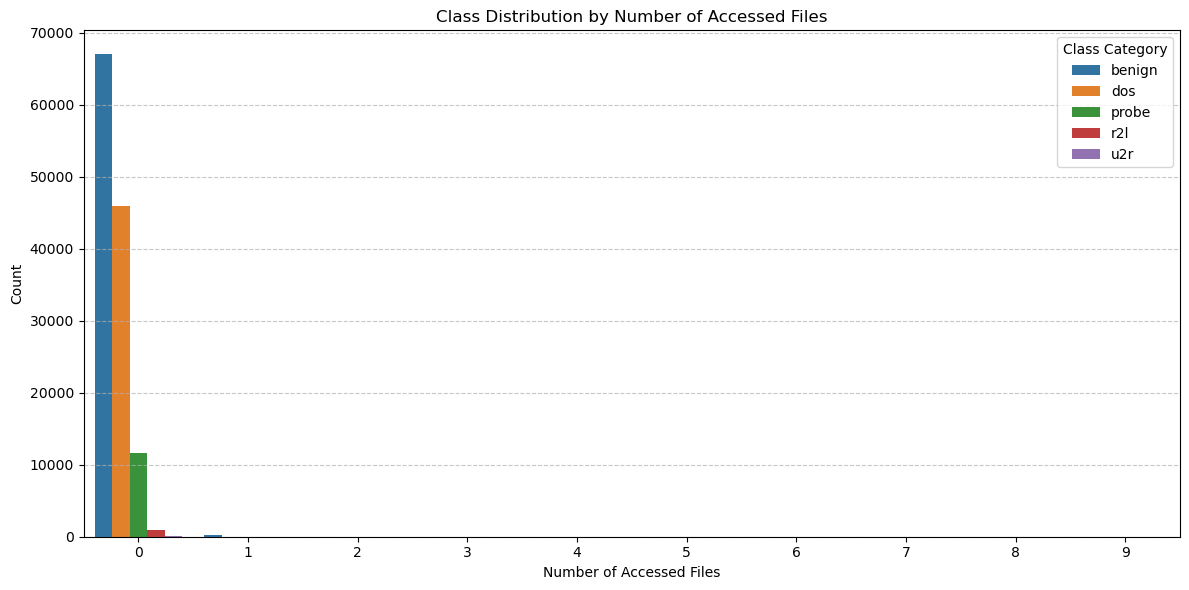

In [1506]:
plt.figure(figsize=(12, 6))
sns.barplot(data=group_counts, x='num_access_files', y='count', hue='class_category', palette='tab10')
plt.title('Class Distribution by Number of Accessed Files')
plt.xlabel('Number of Accessed Files')
plt.ylabel('Count')
plt.legend(title='Class Category')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [1507]:
#Number of failed login attempts during the connection associated with each type of connection
grouped = dataset.groupby(['num_failed_logins', 'class_category'])
# To count the number of rows in each group:
group_counts = grouped.size().reset_index(name='count')
# Display result
print(group_counts)
# 0- means the login was successul, the system was comprimised on first attempt, the hacker knew the credential

    num_failed_logins class_category  count
0                   0         benign  67275
1                   0            dos  45927
2                   0          probe  11655
3                   0            r2l    943
4                   0            u2r     51
5                   1         benign     52
6                   1            r2l     51
7                   1            u2r      1
8                   2         benign      9
9                   3         benign      5
10                  4         benign      2
11                  4          probe      1
12                  5            r2l      1


Number of failed logins by class category(where: 0- no failed logins, 1- one failed attempt, 2- failed attempts, 3- failed attempts, 4- failed attempts, 5-failed attempts ):
num_failed_logins      0   1  2  3  4  5
class_category                          
benign             67275  52  9  5  2  0
dos                45927   0  0  0  0  0
probe              11655   0  0  0  1  0
r2l                  943  51  0  0  0  1
u2r                   51   1  0  0  0  0


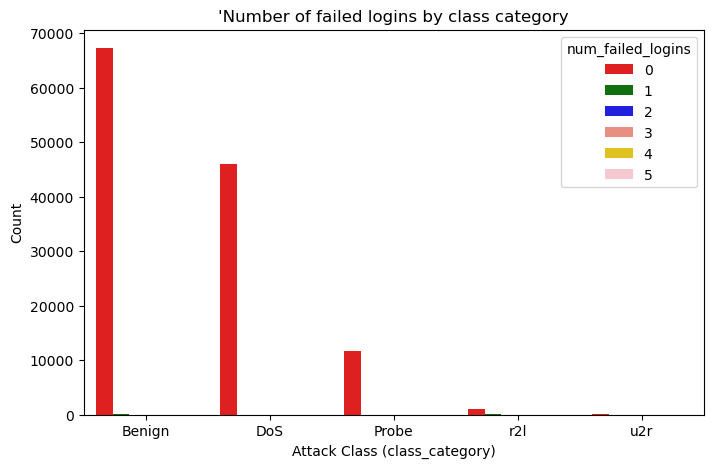

In [1508]:
# 0- means the login was successul, the system was comprimised on first attempt, the hacker knew the credential

result = dataset.groupby('class_category')['num_failed_logins'].value_counts().unstack(fill_value=0)
print('Number of failed logins by class category(where: 0- no failed logins, 1- one failed attempt, 2- failed attempts, 3- failed attempts, 4- failed attempts, 5-failed attempts ):')
print(result)
df_long = result.reset_index().melt(id_vars="class_category", var_name="num_failed_logins", value_name="Count")
plt.figure(figsize=(8, 5))
sns.barplot(x="class_category", y="Count", hue="num_failed_logins", data=df_long, palette=["red", "green","blue","salmon","gold","pink"])
plt.xlabel("Attack Class (class_category)")
plt.ylabel("Count")
plt.title("'Number of failed logins by class category")
plt.xticks([0, 1, 2,3,4], ["Benign", "DoS", "Probe", "r2l","u2r"]) 
plt.show()


In [1509]:
#take the cartegorical data from dataset colums 
categorical_columns=['protocol_type','class','class_category']
 # Get the categorical values into a 2D numpy array
dataset_categorical_values = dataset[categorical_columns]
dataset_categorical_values

,protocol_type,class,class_category
0,tcp,normal,benign
1,udp,normal,benign
2,tcp,neptune,dos
3,tcp,normal,benign
4,tcp,normal,benign
...,...,...,...
125968,tcp,neptune,dos
125969,udp,normal,benign
125970,tcp,normal,benign
125971,tcp,neptune,dos


Classifying attack types in one of the five attack classes: benign, dos, r2l, u2r, or probe by using Decission trees


Encode categorical data

In [1510]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
encoded_dataframe=pd.DataFrame({"protocol_type":dataset["protocol_type"],"protocol_type_encoded":label_encoder.fit_transform(dataset["protocol_type"])})

In [1511]:
#replace the categorical data in the original dataset with the new encoded values
dataset["protocol_type"]=label_encoder.fit_transform(dataset["protocol_type"])

In [1512]:
#visualising it is working
dataset.head()

,protocol_type,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,is_host_login,is_guest_login,count,class,classnum,class_category
0,1,0,0,0,0,0,0,0,0,0,0,0,0,2,normal,20,benign
1,2,0,0,0,0,0,0,0,0,0,0,0,0,13,normal,15,benign
2,1,0,0,0,0,0,0,0,0,0,0,0,0,123,neptune,19,dos
3,1,0,0,1,0,0,0,0,0,0,0,0,0,5,normal,21,benign
4,1,0,0,1,0,0,0,0,0,0,0,0,0,30,normal,21,benign


In [1513]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder=OneHotEncoder()
one_encoder=one_hot_encoder.fit_transform(dataset[["class"]]).toarray()
one_encoder

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [1514]:
#rewrite the dataset with the new data
class_encoded_def=pd.DataFrame(one_encoder,columns=one_hot_encoder.get_feature_names_out(['class']))
#bring the new encoded column in the data set and drop the original
dataset=pd.concat([dataset, class_encoded_def],axis=1,join='inner')
dataset = dataset.drop('class', axis=1)

In [1515]:
#same for class_type
encoder=one_hot_encoder.fit_transform(dataset[["class_category"]]).toarray()
one_encoder

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [1516]:
#rewrite the dataset with the new data
class_category_encoded_def = pd.DataFrame(encoder, columns=one_hot_encoder.get_feature_names_out())
#bring the new encoded column in the data set and drop the original
dataset=pd.concat([dataset, class_category_encoded_def],axis=1,join='inner')
#dataset = dataset.drop('class_category', axis=1)

In [1517]:
dataset.sample(10)

,protocol_type,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,...,class_smurf,class_spy,class_teardrop,class_warezclient,class_warezmaster,class_category_benign,class_category_dos,class_category_probe,class_category_r2l,class_category_u2r
76903,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
97200,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
31028,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
89083,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
41491,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2295,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
124923,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
59501,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
88737,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
81954,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


Training and test data

In [1518]:
#We want to predict attack class by using the observations about atack type features.
#Our target variable is Class category, which we calle y. The features are colled X.
X=dataset.drop('class_category', axis=1)
y=dataset['class_category']
X.head()

,protocol_type,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,...,class_smurf,class_spy,class_teardrop,class_warezclient,class_warezmaster,class_category_benign,class_category_dos,class_category_probe,class_category_r2l,class_category_u2r
0,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


Split the dataset into training and testing dataset
We are going to build a decission tree by using the attack data

In [1519]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)
X_train.head()

,protocol_type,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,...,class_smurf,class_spy,class_teardrop,class_warezclient,class_warezmaster,class_category_benign,class_category_dos,class_category_probe,class_category_r2l,class_category_u2r
49911,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
46670,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
100564,1,0,0,1,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
51601,1,0,0,1,0,0,0,6,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
123170,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [1520]:
y_train.head()

49911     benign
46670        dos
100564    benign
51601     benign
123170    benign
Name: class_category, dtype: object

In [1521]:
X_test.head()

,protocol_type,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,...,class_smurf,class_spy,class_teardrop,class_warezclient,class_warezmaster,class_category_benign,class_category_dos,class_category_probe,class_category_r2l,class_category_u2r
378,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32038,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
86399,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
74412,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
52951,1,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [1522]:
y_test.head()

378      benign
32038       dos
86399       dos
74412       dos
52951     probe
Name: class_category, dtype: object

Create the decision tree

In [1523]:
from sklearn.tree import DecisionTreeClassifier

In [1524]:
clf = DecisionTreeClassifier()
clf = clf.fit(X_train, y_train)

Use the cassifier to make predictions

In [1525]:
y_predict = clf.predict(X_test)

In [1526]:
y_predict

array(['benign', 'dos', 'dos', ..., 'benign', 'benign', 'benign'],
      dtype=object)

Test the accuracy of the classifier

In [1527]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test, y_predict)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 1.0000
Accuracy: 100.00%


In [1528]:
import numpy as np
print(np.unique(y)) 

['benign' 'dos' 'probe' 'r2l' 'u2r']


[Text(0.7142857142857143, 0.9, 'class_category_benign <= 0.5\ngini = 0.572\nsamples = 88181\nvalue = [47260, 32102, 8116, 668, 35]\nclass = benign'),
 Text(0.5714285714285714, 0.7, 'class_category_dos <= 0.5\ngini = 0.345\nsamples = 40921\nvalue = [0, 32102, 8116, 668, 35]\nclass = dos'),
 Text(0.6428571428571428, 0.8, 'True  '),
 Text(0.42857142857142855, 0.5, 'class_category_probe <= 0.5\ngini = 0.147\nsamples = 8819\nvalue = [0.0, 0.0, 8116.0, 668.0, 35.0]\nclass = probe'),
 Text(0.2857142857142857, 0.3, 'class_category_u2r <= 0.5\ngini = 0.095\nsamples = 703\nvalue = [0, 0, 0, 668, 35]\nclass = r2l'),
 Text(0.14285714285714285, 0.1, 'gini = 0.0\nsamples = 668\nvalue = [0, 0, 0, 668, 0]\nclass = r2l'),
 Text(0.42857142857142855, 0.1, 'gini = 0.0\nsamples = 35\nvalue = [0, 0, 0, 0, 35]\nclass = u2l'),
 Text(0.5714285714285714, 0.3, 'gini = 0.0\nsamples = 8116\nvalue = [0, 0, 8116, 0, 0]\nclass = probe'),
 Text(0.7142857142857143, 0.5, 'gini = 0.0\nsamples = 32102\nvalue = [0, 32102, 

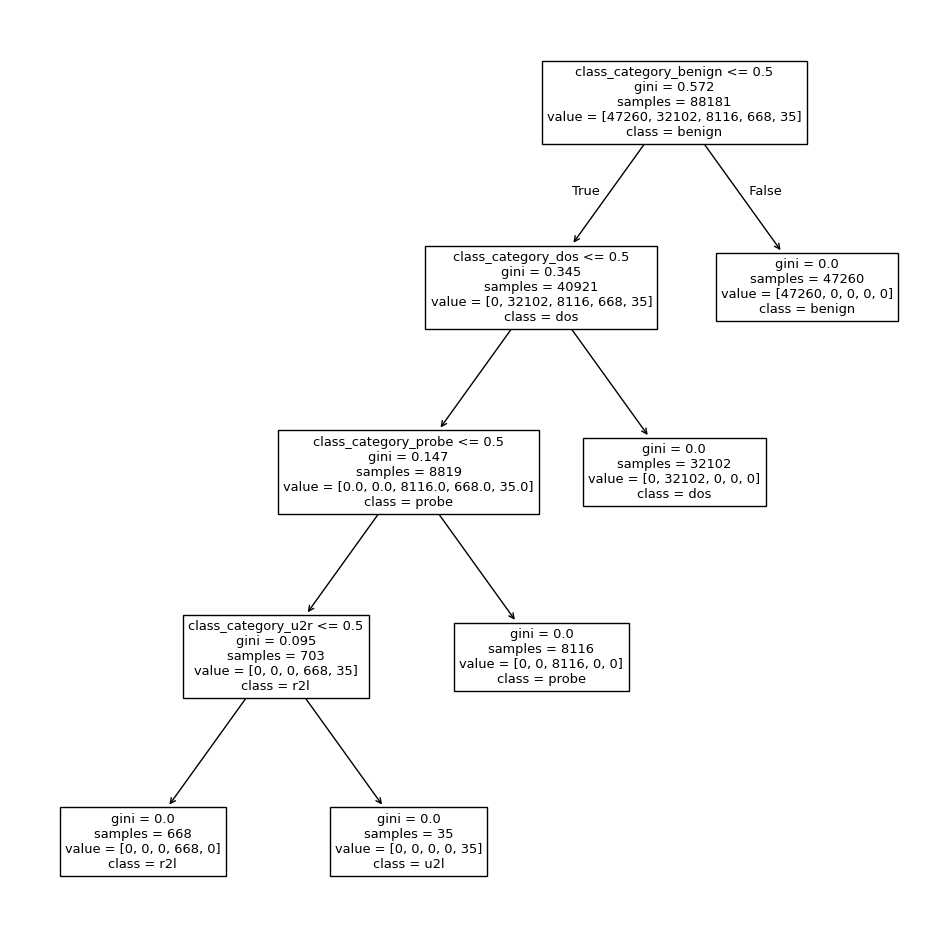

In [1529]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12,12))
plot_tree(clf, feature_names=list(X.columns), class_names=['benign', 'dos', 'probe', 'r2l', 'u2l'])